### Import Dataset

In [47]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [48]:
df = pd.read_csv("../../dataset/SP500_Historical_Data.csv")

In [49]:
df["Price_Spread"] = df["High"] - df["Low"]
df["Price_Change"] = df["Close"] - df["Open"]

In [50]:
features = ["Price_Spread", "Price_Change", "Volume"]
df[features].values.shape


(2703531, 3)

In [68]:
df[features].values

array([[ 6.910000e+00, -4.030000e+00,  4.674353e+06],
       [ 2.470000e+00, -9.700000e-01,  4.765083e+06],
       [ 3.700000e+00, -2.320000e+00,  5.758642e+06],
       ...,
       [ 8.260000e+00,  4.780000e+00,  2.542100e+06],
       [ 5.800000e+00, -6.500000e-01,  3.337100e+06],
       [ 1.294000e+01, -7.250000e+00,  3.257400e+06]])

### Scaling Features

In [33]:
import math

In [77]:
def scale(data_list):
    n = len(data_list)
    # Step 1: mean data list
    mean = sum(data_list) / n
    # Step 2: sum squared difference
    sum_squared_diff = sum((item - mean) ** 2 for item in data_list)
    # Step 3: standard deviation
    std = math.sqrt(sum_squared_diff / n)
    # Step 4: scaled data list
    scaled_data_list = [(item - mean) / std for item in data_list]

    return scaled_data_list

In [69]:
X_original = df[features].values

In [70]:
price_spread_set = X_original[:, 0]
price_change_set = X_original[:, 1]
volume_set = X_original[:, 2]

In [78]:
scaled_price_spread_set = scale(price_spread_set)
scaled_price_change_set = scale(price_change_set)
scaled_volume_set = scale(volume_set)

In [81]:
df_scaled_set = pd.DataFrame(
    {
        "Ticker": df["Ticker"].values,
        "Date": df["Date"].values,
        "Price_Spread": scaled_price_spread_set, 
        "Price_Change": scaled_price_change_set, 
        "Adj Close": df["Adj Close"].values,
        "Volume": scaled_volume_set
    }
)

In [82]:
df_scaled_set

,Ticker,Date,Price_Spread,Price_Change,Adj Close,Volume
0,A,2000-01-03,1.263718,-1.522055,43.04,-0.082172
1,A,2000-01-04,0.179916,-0.368739,39.75,-0.080327
2,A,2000-01-05,0.480159,-0.877555,37.28,-0.060131
3,A,2000-01-06,0.143301,-0.368739,35.86,-0.125671
4,A,2000-01-07,0.587562,1.334853,38.85,-0.119873
...,...,...,...,...,...,...
2703526,ZS,2026-02-13,1.400414,1.270780,177.72,-0.127710
2703527,ZS,2026-02-17,1.344271,-1.220534,172.59,-0.135760
2703528,ZS,2026-02-18,1.593252,1.798441,172.13,-0.125515
2703529,ZS,2026-02-19,0.992768,-0.248130,168.99,-0.109354


### Visualize Dataset

In [83]:
y_labels = np.where(df_scaled_set["Price_Change"] > 0, 1, -1)
df_scaled_set["Target"] = y_labels

In [89]:
plt.figure(figsize=(9, 7))

<Figure size 900x700 with 0 Axes>

<Figure size 900x700 with 0 Axes>

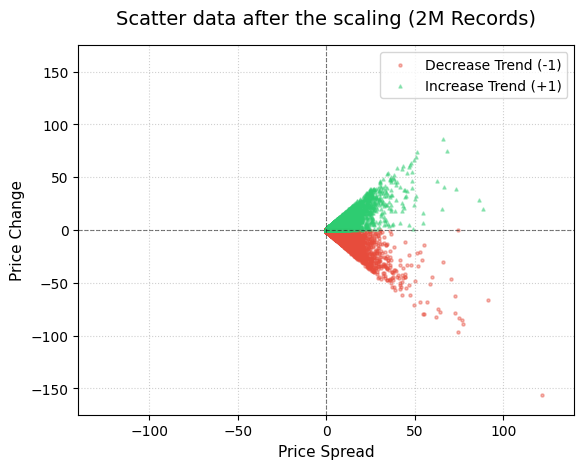

In [110]:
df_decrease = df_scaled_set[df_scaled_set["Target"] == -1]
plt.scatter(
    df_decrease["Price_Spread"],
    df_decrease["Price_Change"],
    s=5,
    color="#e74c3c",
    edgecolors="#e74c3c",
    alpha=0.4,
    label="Decrease Trend (-1)",
    marker="o",
)

df_increase = df_scaled_set[df_scaled_set["Target"] == 1]
plt.scatter(
    df_increase["Price_Spread"],
    df_increase["Price_Change"],
    s=5,
    color="#2ecc71",
    edgecolors="#2ecc71",
    alpha=0.4,
    label="Increase Trend (+1)",
    marker="^",
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

plt.title("Scatter data after the scaling (2M Records)", fontsize=14, pad=15)
plt.xlabel("Price Spread", fontsize=11)
plt.ylabel("Price Change", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.xlim(-140, 140)
plt.ylim(-175, 175)

plt.show()